# Logistic Regression


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Seaborn is a Python data visualization library based on matplotlib
import seaborn as sns
%matplotlib inline

####  0. Importamos los datos

##### El set de datos proviene de aquí: https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset

**RowNumber**: The sequential number assigned to each row in the dataset.  
**CustomerId**: A unique identifier for each customer.  
**Surname**: The surname of the customer.  
**CreditScore**: The credit score of the customer.  
**Geography**: The geographical location of the customer (e.g., country or region).  
**Gender**: The gender of the customer.  
**Age**: The age of the customer.  
**Tenure**: The number of years the customer has been with the bank.  
**Balance**: The account balance of the customer.  
**NumOfProducts**: The number of bank products the customer has.  
**HasCrCard**: Indicates whether the customer has a credit card (binary: yes/no).  
**IsActiveMember**: Indicates whether the customer is an active member (binary: yes/no).  
**EstimatedSalary**: The estimated salary of the customer.  
**Exited**: Indicates whether the customer has exited the bank (binary: yes/no).  

In [2]:
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\04 Aprendizaje supervisado'

In [9]:
file='data\\Churn_Modelling.csv'
df = pd.read_csv(file, delimiter=',', low_memory=False)
df.shape
#os.getcwd()
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

#### 1. Analizamos los datos

In [10]:
# Get the first five rows of DataFrame ad_data.
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.shape

(10000, 14)

In [12]:
# Get a concise summary of DataFrame ad_data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
# Get the statistical summary of the DataFrame ad_data.
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Hay un 20% de clientes exited

#### 1.1 Chequeamos si hay valores nulos

In [14]:
# The isnull() method is used to check and manage NULL values in a data frame.
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### 1.2 Histogramas

In [18]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Surname', 'Geography', 'Gender']
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


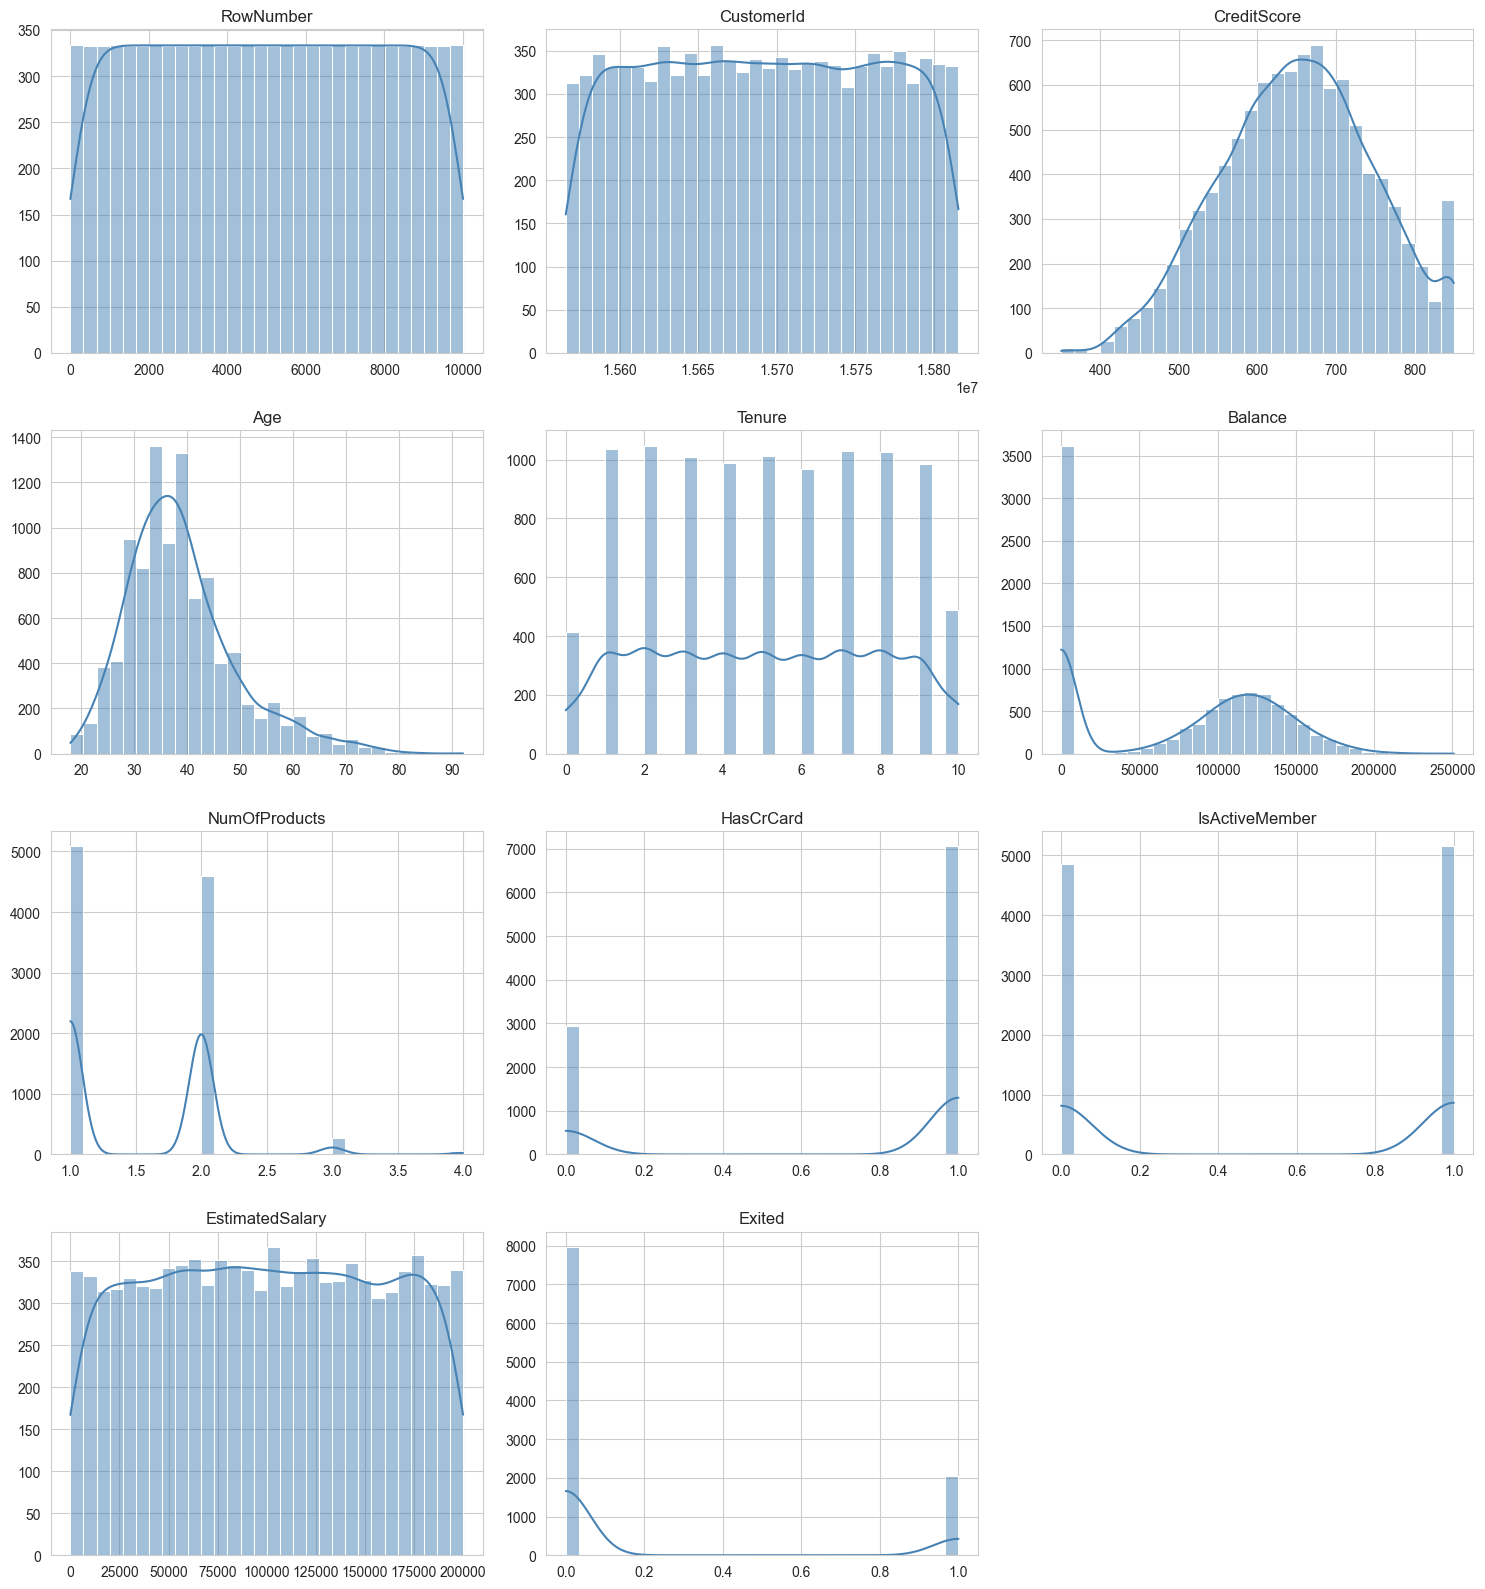

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Supongamos que tienes un DataFrame llamado df y una lista con las variables numéricas
# num_vbles = ['edad', 'glucosa', 'presion', 'colesterol', 'peso', 'altura', ...]

n = len(num_vbles)
cols = 3  # Número de columnas del grid
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*5, rows*4))  # Ajusta el tamaño según tu número de variables

for i, var in enumerate(num_vbles, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[var], bins=30, kde=True, color='steelblue')
    plt.title(var)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


#### 2. Transformamos las variables

In [16]:
df_original = df

**2.1 Eliminamos variables que no vamos a usar**  
El apellido tiene pinta de que va a ser una variable dispersa y no va a aportar al modelo

In [57]:
frecuencias = df['Surname'].value_counts()
frecuencias

Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Wells         1
Calzada       1
Gresswell     1
Aguirre       1
Morales       1
Name: count, Length: 2932, dtype: int64

In [58]:
df.shape

(10000, 14)

In [21]:
df = df.drop(columns=['Surname','RowNumber', 'CustomerId'])

In [22]:
df.shape

(10000, 11)

**2.1 Transformamos las variables categoricas en dummies**

In [23]:
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Geography', 'Gender']
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [24]:
from sklearn.preprocessing import OneHotEncoder
# Crear un objeto OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
#El parámetro sparse_output=False asegura que la salida sea un array denso 
#(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.
for i in cat_vbles:
    encoded_data = encoder.fit_transform(df[[i]])
    column_names = encoder.get_feature_names_out([i])
    encoded_df=pd.DataFrame(encoded_data, columns=column_names)
    df = pd.concat([df, encoded_df], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0


**Eliminamos las variables categoricas una vez las hemos convertido en dummies**  

In [25]:
df = df.drop(columns=cat_vbles)

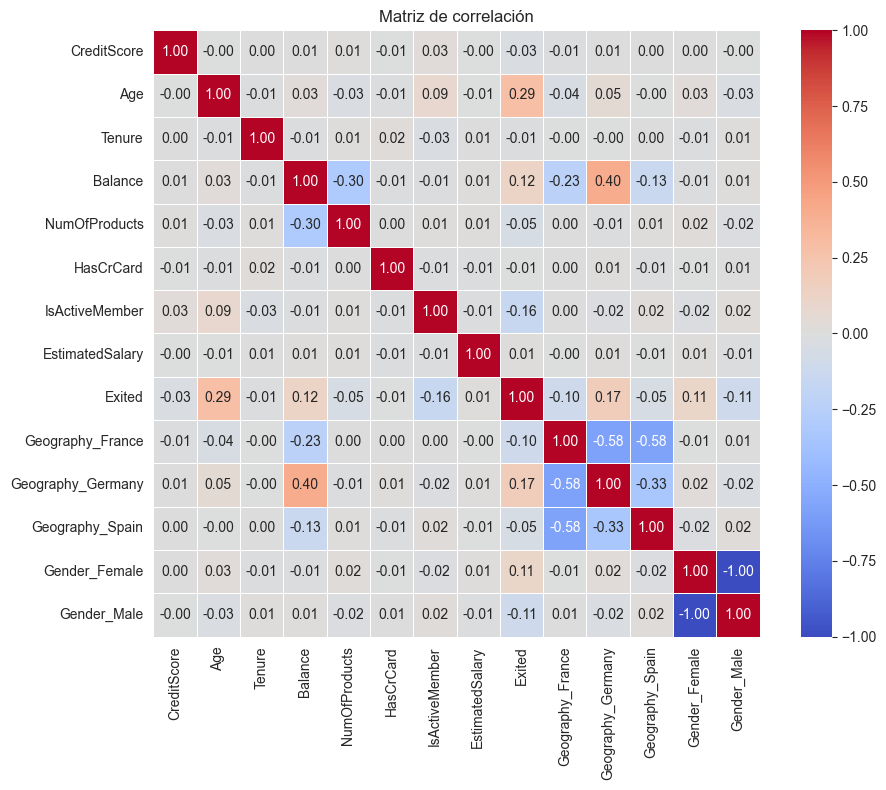

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,             # Muestra los coeficientes
    fmt=".2f",              # Formato de decimales
    cmap='coolwarm',         # Colormap apto para daltónicos: cividis
    square=True,
    linewidths=0.5,
    #linecolor='gray'
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()


####  3. Modelo: Logistic Regression

Básicamente es una regresión lineal con una función de activación al final que nos sirve para predecir una clase u otra. Sirve para clasificar: Ej: el cliente contrata el préstamos o no.

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
frecuencias = df['Exited'].value_counts()
frecuencias

Exited
0    7963
1    2037
Name: count, dtype: int64

In [71]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_X = StandardScaler()

X = df.drop(columns='Exited')
X_scaled = scaler_X.fit_transform(X)
y = df['Exited']

#### 3.1 Separamos en train y test

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [73]:
y_test.value_counts()

Exited
0    2657
1     643
Name: count, dtype: int64

#### 3.2 Entrenamos el modelo

In [74]:
from sklearn.linear_model import LogisticRegression

In [75]:
logmodel = LogisticRegression(max_iter=1000, C=0.01)
logmodel.fit(X_train,y_train)

C:\Users\tomas\ML\cluster\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.01, max_iter=1000)

####  4. Evaluación del modelo

In [76]:
# Use predict() function to predict values for the testing data.
predictions = logmodel.predict(X_test)

#### 4.1 Confusion matrix

In [77]:
from sklearn.metrics import confusion_matrix

In [78]:
cm = confusion_matrix(y_test, predictions, labels=[1, 0])

# Mostrar la matriz de confusión
print("Matriz de Confusión:")
print(cm)

Matriz de Confusión:
[[ 106  537]
 [  68 2589]]


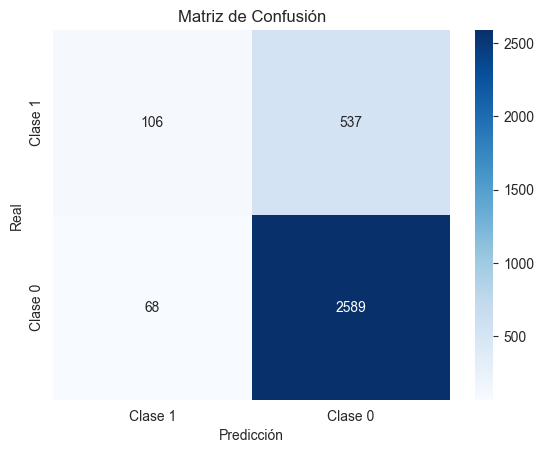

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 1", "Clase 0"], yticklabels=["Clase 1", "Clase 0"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#### 4.2 Clasification report 

In [80]:
# The classification_report function builds a text report showing the main classification metrics.
from sklearn.metrics import classification_report

In [81]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.83      0.97      0.90      2657
           1       0.61      0.16      0.26       643

    accuracy                           0.82      3300
   macro avg       0.72      0.57      0.58      3300
weighted avg       0.79      0.82      0.77      3300



**4.3 Curva ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**

ROC-AUC: 0.76


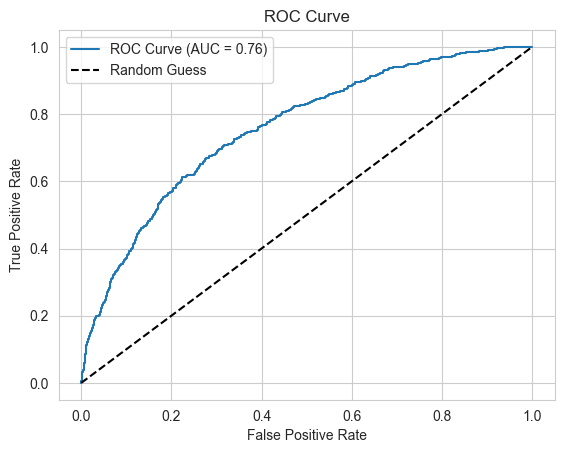

In [82]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Calculamos primero las probabilidades de ser 1 ó 0
pred_proba = logmodel.predict_proba(X_test)[:, 1]

# Calcular ROC-AUC
roc_auc = roc_auc_score(y_test, pred_proba) # Ojo en la curva ROC hay que pasarle las probabilidades de que pertenezca a la clas 1
print(f"ROC-AUC: {roc_auc:.2f}")

# Calcular los valores para la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, pred_proba)

# Graficar la curva ROC
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Línea diagonal para referencia
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 4.4 Kappa del modelo
El **índice Kappa (o Kappa de Cohen)** mide el grado de acuerdo entre las predicciones de un modelo y los valores reales, ajustando por el acuerdo que podría ocurrir por azar.  
El valor del índice Kappa oscila entre: 
* 1: Acuerdo perfecto entre las predicciones y las etiquetas reales.
* 0: Acuerdo puramente aleatorio (sin relación real entre predicciones y etiquetas).
* Valores negativos: Indican un desacuerdo peor que el azar.  

Este índice es útil cuando las clases están desbalanceadas o quieres evaluar la consistencia del modelo más allá de la precisión global.


In [83]:
from sklearn.metrics import cohen_kappa_score

In [84]:
# Calcular el índice Kappa
kappa = cohen_kappa_score(y_test,predictions)

# Mostrar el Kappa
print(f"Índice Kappa: {kappa:.2f}")

Índice Kappa: 0.19


#### 4.5 MCC (Matthews Correlation Coefficient)

El **índice de correlación de Mattews** Mide la calidad de la clasificación considerando todas las categorías de la matriz de confusión.  
Útil cuando: Quieres una métrica equilibrada incluso para datos desbalanceados.  
Rango: De -1 (desempeño malo) a 1 (desempeño perfecto).


In [85]:
from sklearn.metrics import matthews_corrcoef
# Calcular el MCC
mcc = matthews_corrcoef(y_test, predictions)

# Mostrar el resultado
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

Matthews Correlation Coefficient (MCC): 0.25


#### 4.6 Importancia de variables

In [91]:
import pandas as pd
import numpy as np

# Extraer los coeficientes
coeficientes = logmodel.coef_[0]  # Es un array 1D si es binario

# Emparejarlos con los nombres de las variables
importancia = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': coeficientes
})

# Ordenarlos por importancia absoluta
importancia['abs'] = np.abs(importancia['coeficiente'])
importancia = importancia.sort_values(by='abs', ascending=False)

print(importancia[['variable', 'coeficiente']])


             variable   coeficiente
6      IsActiveMember -7.871928e-01
12        Gender_Male -4.413105e-01
10    Geography_Spain -3.430524e-01
8    Geography_France -3.279544e-01
9   Geography_Germany  2.599502e-01
4       NumOfProducts -1.063903e-01
5           HasCrCard -1.046524e-01
1                 Age  5.686514e-02
2              Tenure -3.740861e-02
11      Gender_Female  3.025359e-02
0         CreditScore -2.943189e-03
3             Balance  2.504152e-06
7     EstimatedSalary -7.344740e-07


C:\Users\tomas\AppData\Local\Temp\ipykernel_21532\3061593526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia, x='coeficiente', y='variable', palette='coolwarm')


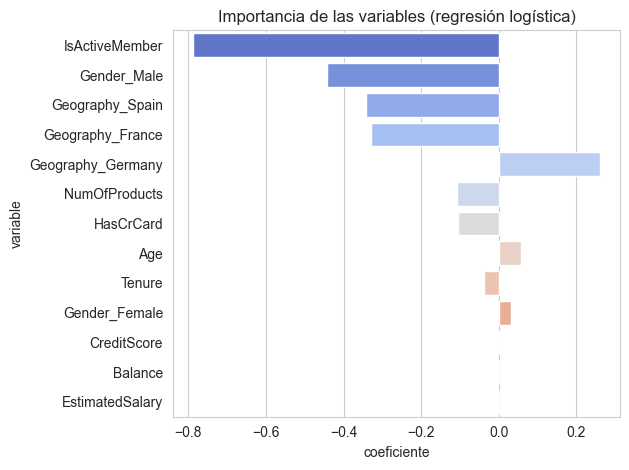

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=importancia, x='coeficiente', y='variable', palette='coolwarm')
plt.title('Importancia de las variables (regresión logística)')
plt.tight_layout()
plt.show()